In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("../Data/raw/Transaction.csv")
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
from sklearn.model_selection  import train_test_split

df_small,_=train_test_split(
  df,
  train_size=200000,
  stratify=df["isFraud"],
  random_state=42
)

In [8]:
print(df_small.shape)

(200000, 11)


In [9]:
df_small.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 3230382 to 4541833
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            200000 non-null  int64  
 1   type            200000 non-null  object 
 2   amount          200000 non-null  float64
 3   nameOrig        200000 non-null  object 
 4   oldbalanceOrg   200000 non-null  float64
 5   newbalanceOrig  200000 non-null  float64
 6   nameDest        200000 non-null  object 
 7   oldbalanceDest  200000 non-null  float64
 8   newbalanceDest  200000 non-null  float64
 9   isFraud         200000 non-null  int64  
 10  isFlaggedFraud  200000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 18.3+ MB


# EDA

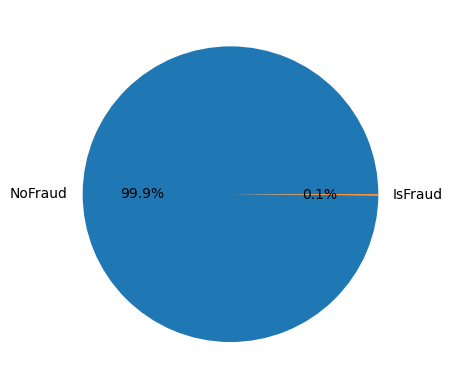

In [10]:
class_count=df_small["isFraud"].value_counts()
plt.pie(class_count,labels=["NoFraud","IsFraud"],autopct="%1.1f%%")
plt.show()

In [11]:
count = (df_small["isFraud"] == 1).sum()
print(count)
df_small.head()

258


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3230382,250,CASH_OUT,281200.68,C1911318394,0.0,0.0,C2013875267,1127597.36,1408798.04,0,0
5421286,378,CASH_OUT,150691.59,C613536510,220.0,0.0,C1480547290,1291956.94,1442648.54,0,0
5567956,393,PAYMENT,16114.01,C1830901026,1340.0,0.0,M892977060,0.00,0.00,0,0
813319,40,CASH_OUT,96210.00,C757735777,0.0,0.0,C534617900,1227907.98,1324117.98,0,0
4939643,350,CASH_OUT,87415.46,C1521110897,0.0,0.0,C863909301,3077418.24,3164833.70,0,0


[Text(0, 0, '2.2375e+06'),
 Text(0, 0, '2.1515e+06'),
 Text(0, 0, '1.39928e+06'),
 Text(0, 0, '532909'),
 Text(0, 0, '41432')]

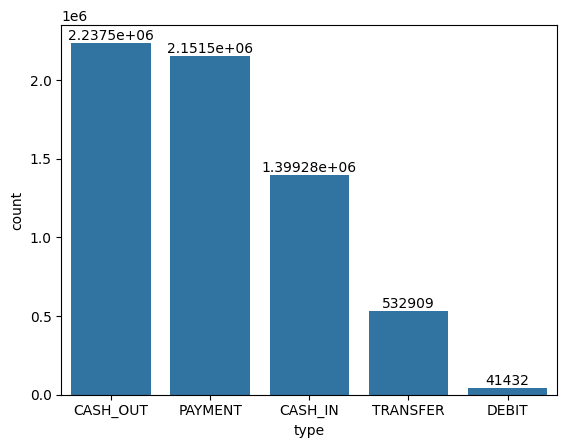

In [12]:
typeCount=df["type"].value_counts()
ax=sns.barplot(typeCount)
ax.bar_label(ax.containers[0])


In [13]:
pd.crosstab(df_small["type"], df_small["isFraud"])

isFraud,0,1
type,,
CASH_IN,43677,0
CASH_OUT,70155,127
DEBIT,1305,0
PAYMENT,67821,0
TRANSFER,16784,131


<Axes: xlabel='type', ylabel='Count'>

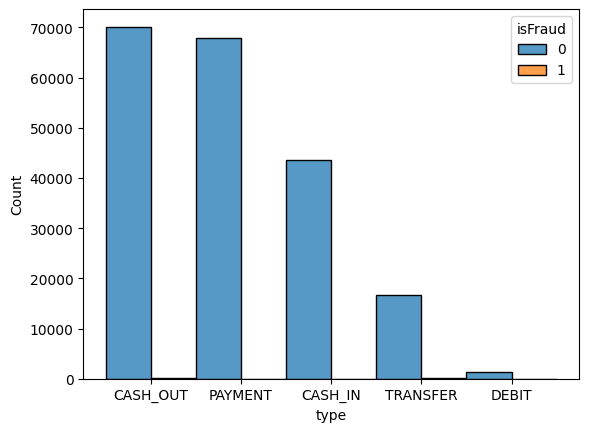

In [14]:
sns.histplot(
  data=df_small,
  x="type",
  hue="isFraud",
  bins=20,
  multiple="dodge"
)

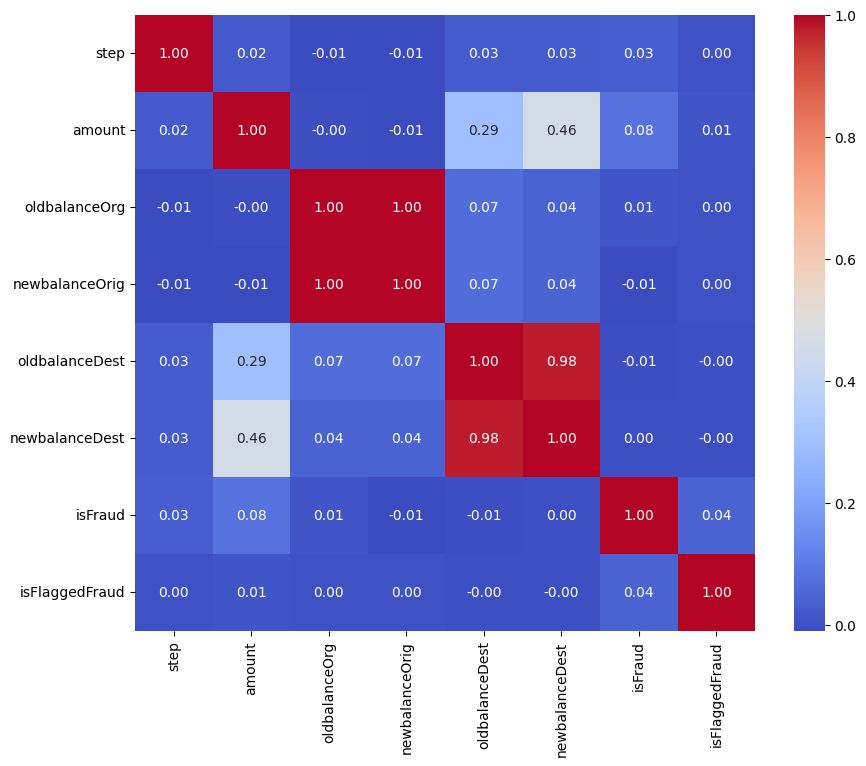

In [15]:
num_cols=df.select_dtypes(include='number')
corr_matrix=num_cols.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
  corr_matrix,
  annot=True,
  fmt=".2f",
  cmap="coolwarm"
)

plt.show()

In [16]:
from sklearn.preprocessing import OneHotEncoder
cols=["type"]

ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

encoded=ohe.fit_transform(df_small[cols])

encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df_small.index)

df_small=pd.concat([df_small.drop(columns=cols),encoded_df],axis=1)

In [17]:
df_small

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
3230382,250,281200.68,C1911318394,0.0,0.00,C2013875267,1127597.36,1408798.04,0,0,1.0,0.0,0.0,0.0
5421286,378,150691.59,C613536510,220.0,0.00,C1480547290,1291956.94,1442648.54,0,0,1.0,0.0,0.0,0.0
5567956,393,16114.01,C1830901026,1340.0,0.00,M892977060,0.00,0.00,0,0,0.0,0.0,1.0,0.0
813319,40,96210.00,C757735777,0.0,0.00,C534617900,1227907.98,1324117.98,0,0,1.0,0.0,0.0,0.0
4939643,350,87415.46,C1521110897,0.0,0.00,C863909301,3077418.24,3164833.70,0,0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5986750,408,5935.22,C1225041669,228254.0,222318.78,M1741889629,0.00,0.00,0,0,0.0,0.0,1.0,0.0
5498478,380,50954.25,C1627171606,21566.0,0.00,C677942230,0.00,50954.25,0,0,1.0,0.0,0.0,0.0
1663828,158,216803.70,C2068361010,31471.0,0.00,C115347060,735043.84,951847.53,0,0,1.0,0.0,0.0,0.0
2155209,184,237448.11,C1071947050,11025.0,0.00,C954747461,207166.47,444614.58,0,0,1.0,0.0,0.0,0.0


In [18]:
cols1=["nameOrig","nameDest","isFraud"]
X=df_small.drop(cols1,axis=1)
y=df_small["isFraud"]

In [19]:
X.sample(10)
y.sample(10)

528589     0
1469902    0
2011662    0
4729771    0
5852454    0
5474811    0
5768389    0
6254644    0
4037530    0
3644620    0
Name: isFraud, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=df_small["isFraud"])

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,confusion_matrix

model=LogisticRegression(max_iter=10000)

model.fit(X_train,y_train)

y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)

print("Training Accuracy Score:-",accuracy_score(y_train,y_pred_train))
print("Training f1 Score:-",f1_score(y_train,y_pred_train))
print("Training recall Score:-",recall_score(y_train,y_pred_train))
print("Training precision Score:-",precision_score(y_train,y_pred_train))
print("confusion Matrix Training:-\n",confusion_matrix(y_train,y_pred_train))
print("\n")
print("Testing Accuracy Score:-",accuracy_score(y_test,y_pred_test))
print("Testing f1 Score:-",f1_score(y_test,y_pred_test))
print("Testing recall Score:-",recall_score(y_test,y_pred_test))
print("Testing precision Score:-",precision_score(y_test,y_pred_test))
print("confusion Matrix Testing:-\n",confusion_matrix(y_test,y_pred_test))

Training Accuracy Score:- 0.99934375
Training f1 Score:- 0.6728971962616822
Training recall Score:- 0.5242718446601942
Training precision Score:- 0.9391304347826087
confusion Matrix Training:-
 [[159787      7]
 [    98    108]]


Testing Accuracy Score:- 0.99915
Testing f1 Score:- 0.5853658536585366
Testing recall Score:- 0.46153846153846156
Testing precision Score:- 0.8
confusion Matrix Testing:-
 [[39942     6]
 [   28    24]]


Training Accuracy Score:- 1.0
Training f1 Score:- 1.0
Training recall Score:- 1.0
Training precision Score:- 1.0
confusion Matrix Training:-
 [[159794      0]
 [     0    206]]


Testing Accuracy Score:- 0.999325
Testing f1 Score:- 0.7428571428571429
Testing recall Score:- 0.75
Testing precision Score:- 0.7358490566037735
confusion Matrix Testing:-
 [[39934    14]
 [   13    39]]


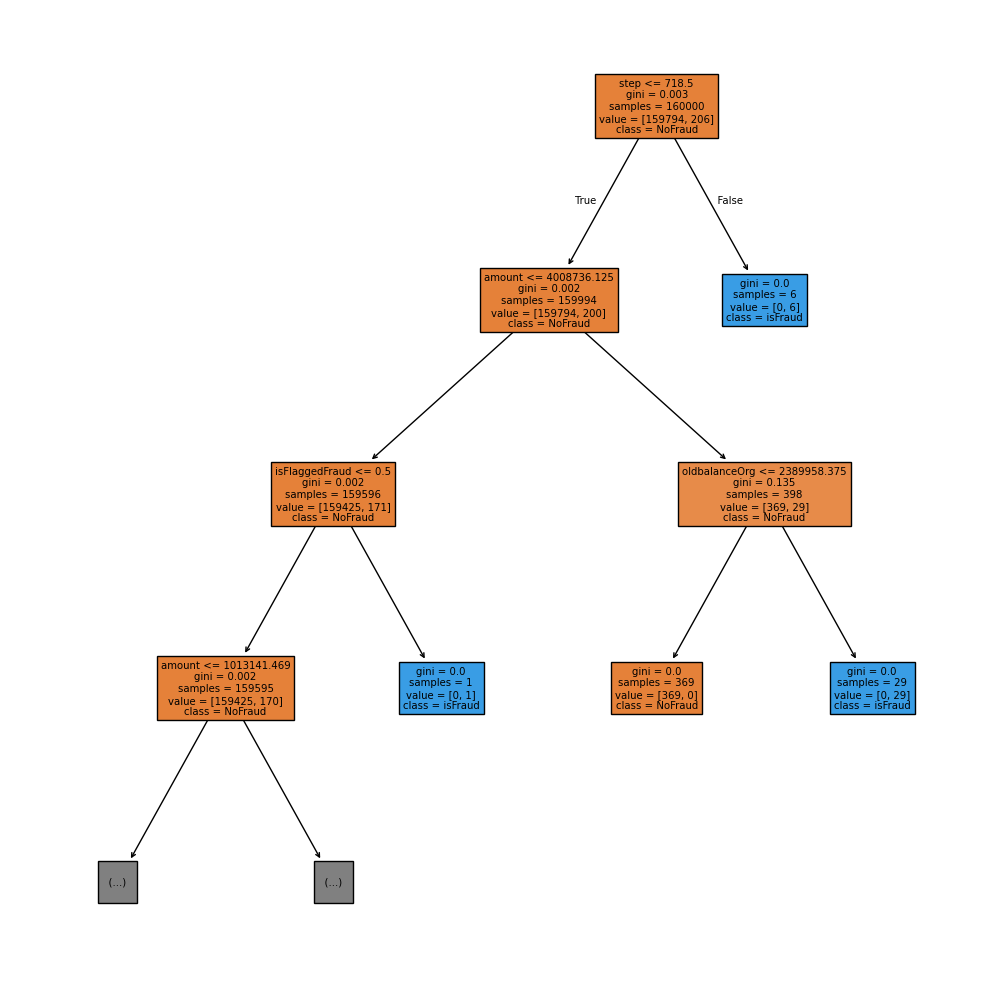

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

dtc=DecisionTreeClassifier()
dtc.fit(X_train,y_train)

y_pred_train=dtc.predict(X_train)
y_pred_test=dtc.predict(X_test)

print("Training Accuracy Score:-",accuracy_score(y_train,y_pred_train))
print("Training f1 Score:-",f1_score(y_train,y_pred_train))
print("Training recall Score:-",recall_score(y_train,y_pred_train))
print("Training precision Score:-",precision_score(y_train,y_pred_train))
print("confusion Matrix Training:-\n",confusion_matrix(y_train,y_pred_train))
print("\n")
print("Testing Accuracy Score:-",accuracy_score(y_test,y_pred_test))
print("Testing f1 Score:-",f1_score(y_test,y_pred_test))
print("Testing recall Score:-",recall_score(y_test,y_pred_test))
print("Testing precision Score:-",precision_score(y_test,y_pred_test))
print("confusion Matrix Testing:-\n",confusion_matrix(y_test,y_pred_test))

plt.figure(figsize=(10,10))
plot_tree(
  dtc,
  feature_names=X.columns,
  class_names=["NoFraud","isFraud"],
  filled=True,
  max_depth=3
)

plt.tight_layout()
plt.show()

In [23]:
from sklearn.ensemble import BaggingClassifier

base_Model=DecisionTreeClassifier()

model=BaggingClassifier(
  base_Model,
  n_estimators=100
)

model.fit(X_train,y_train)

y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)

print("Training Accuracy Score:-",accuracy_score(y_train,y_pred_train))
print("Training f1 Score:-",f1_score(y_train,y_pred_train))
print("Training recall Score:-",recall_score(y_train,y_pred_train))
print("Training precision Score:-",precision_score(y_train,y_pred_train))
print("confusion Matrix Training:-\n",confusion_matrix(y_train,y_pred_train))
print("\n")
print("Testing Accuracy Score:-",accuracy_score(y_test,y_pred_test))
print("Testing f1 Score:-",f1_score(y_test,y_pred_test))
print("Testing recall Score:-",recall_score(y_test,y_pred_test))
print("Testing precision Score:-",precision_score(y_test,y_pred_test))
print("confusion Matrix Testing:-\n",confusion_matrix(y_test,y_pred_test))

Training Accuracy Score:- 1.0
Training f1 Score:- 1.0
Training recall Score:- 1.0
Training precision Score:- 1.0
confusion Matrix Training:-
 [[159794      0]
 [     0    206]]


Testing Accuracy Score:- 0.99965
Testing f1 Score:- 0.8478260869565217
Testing recall Score:- 0.75
Testing precision Score:- 0.975
confusion Matrix Testing:-
 [[39947     1]
 [   13    39]]


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
  n_estimators=500,
  oob_score=True,
)

rf.fit(X_train,y_train)

#Feature Importance
importance=pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(15)


y_pred_train=rf.predict(X_train)
y_pred_test=rf.predict(X_test)

print("Training Accuracy Score:-",accuracy_score(y_train,y_pred_train))
print("Training f1 Score:-",f1_score(y_train,y_pred_train))
print("Training recall Score:-",recall_score(y_train,y_pred_train))
print("Training precision Score:-",precision_score(y_train,y_pred_train))
print("confusion Matrix Training:-\n",confusion_matrix(y_train,y_pred_train))
print("\n")
print("Testing Accuracy Score:-",accuracy_score(y_test,y_pred_test))
print("Testing f1 Score:-",f1_score(y_test,y_pred_test))
print("Testing recall Score:-",recall_score(y_test,y_pred_test))
print("Testing precision Score:-",precision_score(y_test,y_pred_test))
print("confusion Matrix Testing:-\n",confusion_matrix(y_test,y_pred_test))


Training Accuracy Score:- 1.0
Training f1 Score:- 1.0
Training recall Score:- 1.0
Training precision Score:- 1.0
confusion Matrix Training:-
 [[159794      0]
 [     0    206]]


Testing Accuracy Score:- 0.9996
Testing f1 Score:- 0.8222222222222222
Testing recall Score:- 0.7115384615384616
Testing precision Score:- 0.9736842105263158
confusion Matrix Testing:-
 [[39947     1]
 [   15    37]]


In [25]:
import xgboost as xgb

xgb_clf=xgb.XGBClassifier(
  n_estimators=500,
  learning_rate=0.1,
  max_depth=4,
  random_state=42
)

xgb_clf.fit(X_train,y_train)

y_pred_train=xgb_clf.predict(X_train)
y_pred_test=xgb_clf.predict(X_test)

print("Training Accuracy Score:-",accuracy_score(y_train,y_pred_train))
print("Training f1 Score:-",f1_score(y_train,y_pred_train))
print("Training recall Score:-",recall_score(y_train,y_pred_train))
print("Training precision Score:-",precision_score(y_train,y_pred_train))
print("confusion Matrix Training:-\n",confusion_matrix(y_train,y_pred_train))
print("\n")
print("Testing Accuracy Score:-",accuracy_score(y_test,y_pred_test))
print("Testing f1 Score:-",f1_score(y_test,y_pred_test))
print("Testing recall Score:-",recall_score(y_test,y_pred_test))
print("Testing precision Score:-",precision_score(y_test,y_pred_test))
print("confusion Matrix Testing:-\n",confusion_matrix(y_test,y_pred_test))


Training Accuracy Score:- 1.0
Training f1 Score:- 1.0
Training recall Score:- 1.0
Training precision Score:- 1.0
confusion Matrix Training:-
 [[159794      0]
 [     0    206]]


Testing Accuracy Score:- 0.999675
Testing f1 Score:- 0.8602150537634409
Testing recall Score:- 0.7692307692307693
Testing precision Score:- 0.975609756097561
confusion Matrix Testing:-
 [[39947     1]
 [   12    40]]


In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [4,5,6,10,15],
    "learning_rate":[0.01,0.05,0.1,0.2,0.5,1]
}

random_search = RandomizedSearchCV(
    xgb_clf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)

{'n_estimators': 400, 'max_depth': 15, 'learning_rate': 0.1}


In [27]:
import xgboost as xgb

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_clf=xgb.XGBClassifier(
  scale_pos_weight=scale_pos_weight,
  n_estimators=500,
  learning_rate=0.1,
  max_depth=15,
  random_state=42
)

xgb_clf.fit(X_train,y_train)

y_pred_train=xgb_clf.predict(X_train)
y_pred_test=xgb_clf.predict(X_test)

print("Training Accuracy Score:-",accuracy_score(y_train,y_pred_train))
print("Training f1 Score:-",f1_score(y_train,y_pred_train))
print("Training recall Score:-",recall_score(y_train,y_pred_train))
print("Training precision Score:-",precision_score(y_train,y_pred_train))
print("confusion Matrix Training:-\n",confusion_matrix(y_train,y_pred_train))
print("\n")
print("Testing Accuracy Score:-",accuracy_score(y_test,y_pred_test))
print("Testing f1 Score:-",f1_score(y_test,y_pred_test))
print("Testing recall Score:-",recall_score(y_test,y_pred_test))
print("Testing precision Score:-",precision_score(y_test,y_pred_test))
print("confusion Matrix Testing:-\n",confusion_matrix(y_test,y_pred_test))

Training Accuracy Score:- 1.0
Training f1 Score:- 1.0
Training recall Score:- 1.0
Training precision Score:- 1.0
confusion Matrix Training:-
 [[159794      0]
 [     0    206]]


Testing Accuracy Score:- 0.999625
Testing f1 Score:- 0.845360824742268
Testing recall Score:- 0.7884615384615384
Testing precision Score:- 0.9111111111111111
confusion Matrix Testing:-
 [[39944     4]
 [   11    41]]
